In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
housing=fetch_california_housing()
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
x=housing.data[:,2]
y=housing.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [6]:
m=0
c=0
l=0.001
n=len(x_train)
for i in range(1000):
  y_predict=m*x_train+c
  dm=(-2/n)*np.sum(x_train*(y_train-y_predict))
  dc=(-2/n)*np.sum(y_train-y_predict)
  m-=l*dm
  c-=l*dc
y_predict_gd=m*x_test+c
print(m,c,mean_squared_error(y_test,y_predict_gd),r2_score(y_test,y_predict_gd))

0.25797761849057654 0.4850206129374197 1.6449229482854868 -0.2552744796465303


In [7]:
ones=np.ones(len(x_train))
x_matrix=np.column_stack((ones,x_train))
theta=np.linalg.inv(x_matrix.T @ x_matrix) @(x_matrix.T @ y_train)
print(theta)

[1.65476227 0.07675559]


In [8]:
ones_test=np.ones(len(x_test))
x_test_matrix=np.column_stack((ones_test,x_test))
y_predict_normal=x_test_matrix @ theta
print(mean_squared_error(y_test,y_predict_normal),r2_score(y_test,y_predict_normal))

1.2923314440807283 0.013795337532286012


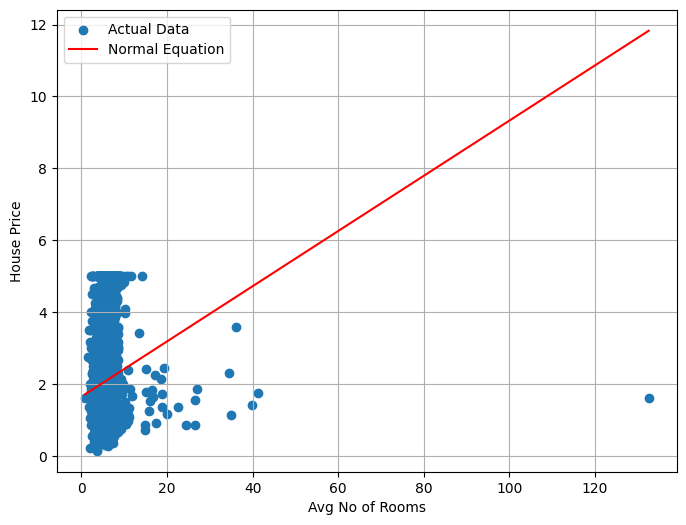

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(x_test,y_test,label="Actual Data")
x_line=np.linspace(min(x_test),max(x_test),100)
plt.plot(x_line,theta[0]+theta[1]*x_line,color="red",label="Normal Equation")
plt.xlabel("Avg No of Rooms")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()